In [21]:
from torch.utils.data import Dataset
from PIL import Image
import io

class ImageNetParquetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_bytes = row["image"]["bytes"]
        label = row["label"]

        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


In [22]:
import glob
import pandas as pd

files = sorted(glob.glob("/home/shared/data/imagenet/validation-*.parquet"))
print(files)  # sanity check

df = pd.read_parquet(files)

['/home/shared/data/imagenet/validation-00000-of-00014.parquet', '/home/shared/data/imagenet/validation-00001-of-00014.parquet', '/home/shared/data/imagenet/validation-00002-of-00014.parquet', '/home/shared/data/imagenet/validation-00003-of-00014.parquet', '/home/shared/data/imagenet/validation-00004-of-00014.parquet', '/home/shared/data/imagenet/validation-00005-of-00014.parquet', '/home/shared/data/imagenet/validation-00006-of-00014.parquet', '/home/shared/data/imagenet/validation-00007-of-00014.parquet', '/home/shared/data/imagenet/validation-00008-of-00014.parquet', '/home/shared/data/imagenet/validation-00009-of-00014.parquet', '/home/shared/data/imagenet/validation-00010-of-00014.parquet', '/home/shared/data/imagenet/validation-00011-of-00014.parquet', '/home/shared/data/imagenet/validation-00012-of-00014.parquet', '/home/shared/data/imagenet/validation-00013-of-00014.parquet']


In [ ]:

print(len(df))


['/home/shared/data/imagenet/validation-00000-of-00014.parquet', '/home/shared/data/imagenet/validation-00001-of-00014.parquet', '/home/shared/data/imagenet/validation-00002-of-00014.parquet', '/home/shared/data/imagenet/validation-00003-of-00014.parquet', '/home/shared/data/imagenet/validation-00004-of-00014.parquet', '/home/shared/data/imagenet/validation-00005-of-00014.parquet', '/home/shared/data/imagenet/validation-00006-of-00014.parquet', '/home/shared/data/imagenet/validation-00007-of-00014.parquet', '/home/shared/data/imagenet/validation-00008-of-00014.parquet', '/home/shared/data/imagenet/validation-00009-of-00014.parquet', '/home/shared/data/imagenet/validation-00010-of-00014.parquet', '/home/shared/data/imagenet/validation-00011-of-00014.parquet', '/home/shared/data/imagenet/validation-00012-of-00014.parquet', '/home/shared/data/imagenet/validation-00013-of-00014.parquet']
50000


In [2]:
import numpy as np

SEED = 42
TEST_SAMPLES_PER_CLASS = 32

# Shuffle within each class, then split
test_df = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=TEST_SAMPLES_PER_CLASS, random_state=SEED))
)

train_df = df.drop(test_df.index)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 18000
Test size: 32000


/tmp/ipykernel_120976/2626809283.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=TEST_SAMPLES_PER_CLASS, random_state=SEED))


In [3]:
test_df["label"].value_counts()


label
999    32
0      32
1      32
2      32
3      32
       ..
12     32
11     32
10     32
9      32
8      32
Name: count, Length: 1000, dtype: int64

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import io

class ImageNetParquetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_bytes = row["image"]["bytes"]
        label = row["label"]

        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


In [5]:
import torch
from torchvision import models

weights = models.ResNet50_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [31]:
dataset = ImageNetParquetDataset(
    df,
    transform=preprocess
)

In [7]:
import torch
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = models.ResNet50_Weights.IMAGENET1K_V1
model = models.resnet50(weights=weights)

# Remove classification head
model.fc = torch.nn.Identity()
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

tensor([[[-2.0152, -1.7583, -1.9638,  ..., -1.8610, -1.7069, -2.0152],
         [-2.0152, -1.7583, -1.9638,  ..., -1.8439, -1.6898, -2.0152],
         [-2.0152, -1.7754, -1.9809,  ..., -1.8268, -1.6727, -2.0152],
         ...,
         [-1.9638, -0.7993, -0.3541,  ..., -0.0972, -0.5938, -1.9295],
         [-1.9638, -0.7822, -0.3369,  ..., -0.4397, -0.7137, -1.9295],
         [-1.9638, -0.7650, -0.2856,  ..., -0.3369, -0.6794, -1.9467]],

        [[-1.9307, -1.5805, -1.7031,  ..., -1.5280, -1.4755, -1.9307],
         [-1.9132, -1.5980, -1.7381,  ..., -1.5280, -1.4755, -1.9132],
         [-1.9132, -1.6155, -1.7556,  ..., -1.5105, -1.4930, -1.9307],
         ...,
         [-1.8606, -0.5476,  0.0126,  ..., -0.4951, -0.8277, -1.8957],
         [-1.8782, -0.5126,  0.0651,  ..., -0.8277, -0.9153, -1.8606],
         [-1.8782, -0.4951,  0.1176,  ..., -0.7577, -0.8803, -1.8782]],

        [[-1.6824, -1.5604, -1.7696,  ..., -1.7870, -1.5256, -1.6650],
         [-1.7173, -1.5430, -1.7870,  ..., -1

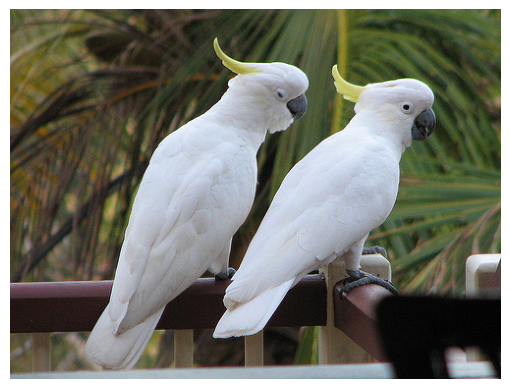

In [ ]:
from PIL import Image
import io
import matplotlib.pyplot as plt

# Get the image bytes
img_bytes = df.loc[10, 'image']['bytes']

# Convert bytes → PIL Image
img = Image.open(io.BytesIO(img_bytes))

# Plot
plt.imshow(img)
plt.axis("off")
plt.show()


---

In [ ]:
train_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute_old/train.pt"))
val_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute_old/validation.pt"))
test_dataset = PreSavedBatchDataset(torch.load("/home/shared/data/shape_unique_single_attribute_old/test.pt"))

In [ ]:
def plot_images(imgs):
    n = len(imgs)
    cols = 5
    rows = int(np.ceil(n / cols))
    
    plt.figure(figsize=(cols * 3, rows * 3))
    
    for i, img in enumerate(imgs):
        plt.subplot(rows, cols, i + 1)
        
        # Handle grayscale vs RGB
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [ ]:
len(val_dataset)

In [ ]:
plot_images(train_dataset[random.randint(0, 70)][0])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import random    

class SingleDigitPadded(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]

        # Decide randomly whether the digit is on the left or right
        if random.random() < 0.5:
            # digit on left
            empty = torch.zeros_like(img)
            image = torch.cat((img, empty), dim=2)  # 28x56
            position = "left"
        else:
            # digit on right
            empty = torch.zeros_like(img)
            image = torch.cat((empty, img), dim=2)
            position = "right"

        return image, label, position
    

class TwoDigitOpposite(Dataset):
    def __init__(self, padded_dataset):
        """
        padded_dataset: your SingleDigitPadded dataset
        """
        self.images = padded_dataset["images"]
        self.positions = padded_dataset["positions"]
        self.labels = padded_dataset["labels"]

        # Precompute indices by position for faster sampling
        self.left_indices = [i for i in range(len(self.images)) if self.positions[i] == "left"]
        self.right_indices = [i for i in range(len(self.images)) if self.positions[i] == "right"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # First sample (fixed)
        img1, label1, pos1 = self.images[idx], self.labels[idx], self.positions[idx]

        # Determine opposite position
        opposite_pos = "right" if pos1 == "left" else "left"
        candidate_indices = self.right_indices if opposite_pos == "right" else self.left_indices

        # Randomly select second sample with opposite position
        random.seed(42)
        idx2 = random.choice(candidate_indices)
        img2, label2 = self.images[idx2], self.labels[idx2]

        # Combine images by adding (keep same shape)
        two_digit_img = img1 + img2
        two_digit_label = (label1, label2) if pos1 == "left" else (label2, label1)

        return two_digit_img, two_digit_label

    
def create_mnist1():
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    train_dataset = datasets.MNIST(
        root="/home/shared/data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.MNIST(
        root="/home/shared/data",
        train=False,
        download=True,
        transform=transform
    )


    singleDigit_train = SingleDigitPadded(train_dataset)
    singleDigit_test = SingleDigitPadded(test_dataset)

    train_loader = DataLoader(singleDigit_train, batch_size=len(singleDigit_train))  
    test_loader = DataLoader(singleDigit_test, batch_size=len(singleDigit_test)) 

    for images, labels, positions in train_loader:
        torch.save({
            'images': images,        # Tensor [N, 1, 28, 56]
            'labels': labels,
            'positions': positions  
        }, '/home/shared/data/MNIST2/train.pt')
        break  # only one batch needed

    for images, labels, positions in test_loader:
        torch.save({
            'images': images,        # Tensor [N, 1, 28, 56]
            'labels': labels,
            'positions': positions
        }, '/home/shared/data/MNIST2/test.pt')
        break  # only one batch needed


def create_mnist2():
    singleDigit = torch.load('/home/shared/data/MNIST1/test.pt')
    
    two_digit_dataset = TwoDigitOpposite(singleDigit)

    # Save the dataset
    loader = DataLoader(two_digit_dataset, batch_size=len(two_digit_dataset))

    for images, labels in loader:
        torch.save({
            'images': images,        # Tensor [N, 1, 28, 56]
            'labels': labels[0] * 10 + labels[1],
        }, '/home/shared/data/MNIST2/test.pt')
        break

In [46]:
create_mnist2()

In [47]:
import torch
singleDigit = torch.load('/home/shared/data/MNIST2/test.pt')

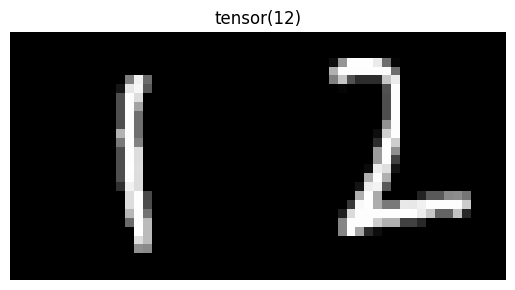

In [104]:
import matplotlib.pyplot as plt
import random
i = random.randint(0, 2000)
plt.imshow(singleDigit['images'][i].permute(1, 2, 0), cmap='gray')
plt.title(singleDigit['labels'][i])
plt.axis('off')
plt.show()

# Analysis